# **Tutorial 07 - Sparse Recovery and Basis Pursuit**: Supplementary Interactive Material

-------------------------------------------------------------------------

Tutorial 06 introduced the $\ell_1$ penalty as a way of shaping a solution. Here we use it to *select* one: given an underdetermined system $Ax = b$, we look for the sparsest $x$ that explains the data.


In [ ]:
import numpy as np, matplotlib.pyplot as plt
import random


## Basis Pursuit with Denoising

In this example, we explore an application of **basis pursuit with denoising**.

In **basis pursuit**, we seek a sparse solution to the linear system

$$
Ax = b
$$

by minimizing

$$
\|x\|_1
$$

subject to the constraint

$$
\|Ax - b\|_2 = 0.
$$

If our signal is noisy, we may allow for some tolerance, i.e.,

$$
\|Ax - b\|_2 < \varepsilon.
$$

---

Here, we look at a collection of human faces:



In [5]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
X = faces.data      # shape (400 faces, 4096 pixels)
y = faces.target

# Each column of A should be one face vector
A = X.T                # now shape (4096, 400); each column is a face (n=4096 pixels, m=400 samples)

In [6]:
X.shape

(400, 4096)

Here we use the classic *Olivetti Faces* dataset from `scikit-learn`. Each image (64×64 grayscale) is flattened into an $n \times 1$ vector, and these vectors form the columns of

$$
A = [\,a_1 \; a_2 \; \cdots \; a_m\,] \in \mathbb{R}^{n \times m}.
$$

We then aim to select a subset of representative faces (columns of $A$). Given a **corrupted face** $b \in \mathbb{R}^n$, the task is to reconstruct it as

$$
b \;\approx\; A x,
$$

with $x$ sparse.  
Basis pursuit with denoising enforces this sparsity, allowing us to recover $b$ from only a few clean face images while tolerating noise or missing pixels.


In [23]:
rng = np.random.default_rng(0)

# pick a random face index
idx_target = random.randint(0, A.shape[1]-1)
b_true = A[:, idx_target]

# remove that face from the dictionary
A_dict = np.delete(A, idx_target, axis=1)

# corruption mask
missing_frac = 0.7   # fraction of pixels to remove
mask = rng.random(b_true.shape) > missing_frac   # True = keep pixel
M = np.diag(mask.astype(float))

# apply mask to target and dictionary
b_obs = M @ b_true
A_masked = M @ A_dict


In [24]:
def soft_threshold(z, alpha):
    return np.sign(z) * np.maximum(np.abs(z) - alpha, 0.0)
    
def ista(A, b, lam=1e-2, max_iter=1500, tol=1e-4):
    L = np.linalg.norm(A, 2)**2
    step = 1.0 / L
    x = np.zeros(A.shape[1])
    for it in range(max_iter):
        grad = A.T @ (A @ x - b)
        x_new = soft_threshold(x - step * grad, lam * step)
        if np.linalg.norm(x_new - x) < tol:
            print(f"Converged at iteration {it+1} (tolerance reached)")
            return x_new
        x = x_new
    print("Reached max_iter without meeting tolerance")
    return x

x_hat = ista(A_masked, b_obs, lam=2) #<- Change lambda here 
b_recon = A_dict @ x_hat
# overwrite the observed entries with the ground truth
b_recon[mask] = b_true[mask]


Converged at iteration 604 (tolerance reached)


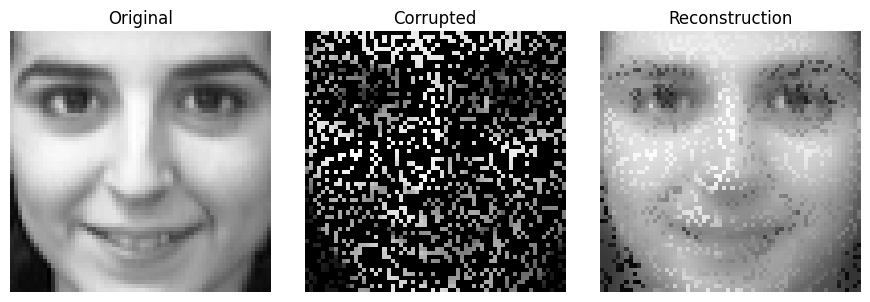

In [25]:
def show_img(vec, title):
    plt.imshow(vec.reshape((64,64)), cmap="gray")
    plt.axis("off")
    plt.title(title)

plt.figure(figsize=(9,3))
plt.subplot(1,3,1); show_img(b_true, "Original")
plt.subplot(1,3,2); show_img(b_obs, "Corrupted")
plt.subplot(1,3,3); show_img(b_recon, "Reconstruction")
plt.tight_layout()
plt.show()


Here, we may observe which faces were used in the reconstruction! Try different lambdas and see how that effecst sparsity.

**Inspecting our Combination**

Here, we observe the faces used in our reconstruction, you are invited to play around with the penaltry strength $\lambda$ and see what effect it has on the makeup.

Try: $\lambda = 1,10,100$ and see what difference it makes!

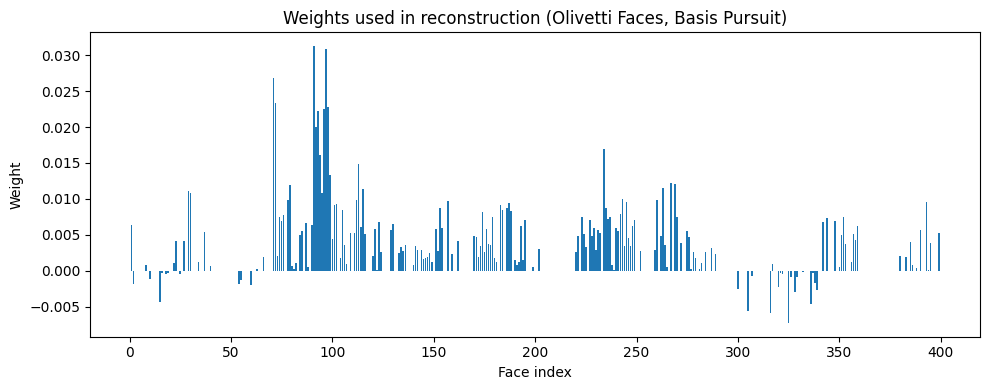

In [26]:
plt.figure(figsize=(10,4))
plt.bar(np.arange(1, len(x_hat)+1), x_hat)
plt.title("Weights used in reconstruction (Olivetti Faces, Basis Pursuit)")
plt.xlabel("Face index")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()